# EDA — Diabetes Health Indicators (BRFSS 2015)

**Pregunta de negocio:** ¿Es posible identificar personas con mayor probabilidad de presentar diabetes a partir de sus indicadores de salud y características sociodemográficas?

**Dataset:** `diabetes_binary_health_indicators_BRFSS2015.csv`

**Variable objetivo:** `Diabetes_binary` (0 = No diabetes, 1 = Diabetes)

Este notebook cubre únicamente el **Análisis Exploratorio de Datos (EDA)**: comprensión de las variables, calidad de los datos, distribución del target y relaciones entre el target y los principales indicadores de salud. El modelado se aborda en un notebook posterior.

## 0. Diccionario de variables

Descripción de cada columna del dataset, basada en el codebook del BRFSS 2015.

| Variable | Descripción | Valores |
|---|---|---|
| `Diabetes_binary` | Variable objetivo: diagnóstico de diabetes o prediabetes | 0 = No diabetes · 1 = Prediabetes o diabetes |
| `HighBP` | Presión arterial alta diagnosticada | 0 = No · 1 = Sí |
| `HighChol` | Colesterol alto diagnosticado | 0 = No · 1 = Sí |
| `CholCheck` | Chequeo de colesterol en los últimos 5 años | 0 = No · 1 = Sí |
| `BMI` | Índice de masa corporal (Body Mass Index) | Valor numérico |
| `Smoker` | ¿Ha fumado al menos 100 cigarrillos en su vida? | 0 = No · 1 = Sí |
| `Stroke` | ¿Le han diagnosticado alguna vez un accidente cerebrovascular (ACV)? | 0 = No · 1 = Sí |
| `HeartDiseaseorAttack` | Enfermedad coronaria o infarto de miocardio | 0 = No · 1 = Sí |
| `PhysActivity` | Actividad física en los últimos 30 días (sin contar el trabajo) | 0 = No · 1 = Sí |
| `Fruits` | Consume fruta 1 o más veces al día | 0 = No · 1 = Sí |
| `Veggies` | Consume vegetales 1 o más veces al día | 0 = No · 1 = Sí |
| `HvyAlcoholConsump` | Consumo excesivo de alcohol (hombres ≥14 tragos/semana, mujeres ≥7 tragos/semana) | 0 = No · 1 = Sí |
| `AnyHealthcare` | Cuenta con algún tipo de cobertura de salud | 0 = No · 1 = Sí |
| `NoDocbcCost` | En los últimos 12 meses, ¿necesitó ver a un médico pero no pudo por el costo? | 0 = No · 1 = Sí |
| `GenHlth` | Autopercepción de salud general | 1 = Excelente · 2 = Muy buena · 3 = Buena · 4 = Regular · 5 = Mala |
| `MentHlth` | Días de mala salud mental en los últimos 30 días | 0 a 30 |
| `PhysHlth` | Días de mala salud física (enfermedad o lesión) en los últimos 30 días | 0 a 30 |
| `DiffWalk` | Dificultad seria para caminar o subir escaleras | 0 = No · 1 = Sí |
| `Sex` | Sexo | 0 = Mujer · 1 = Hombre |
| `Age` | Categoría de edad en rangos de 5 años (`_AGEG5YR`) | 1 = 18-24 · 2 = 25-29 · 3 = 30-34 · 4 = 35-39 · 5 = 40-44 · 6 = 45-49 · 7 = 50-54 · 8 = 55-59 · 9 = 60-64 · 10 = 65-69 · 11 = 70-74 · 12 = 75-79 · 13 = 80 o más |
| `Education` | Nivel educativo alcanzado | 1 = Nunca asistió / solo preescolar · 2 = Primaria (grados 1-8) · 3 = Algo de secundaria (grados 9-11) · 4 = Secundaria completa (grado 12 o GED) · 5 = Algo de universidad o técnico (1-3 años) · 6 = Universidad completa (4 años o más) |
| `Income` | Nivel de ingreso anual del hogar | 1 = menos de $10,000 · 2 = $10,000-$15,000 · 3 = $15,000-$20,000 · 4 = $20,000-$25,000 · 5 = $25,000-$35,000 · 6 = $35,000-$50,000 · 7 = $50,000-$75,000 · 8 = $75,000 o más |

Con este contexto claro, procedemos a cargar y explorar los datos.

## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")
df.shape

(253680, 22)

In [2]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

## 2. Calidad de los datos

Revisamos tipos de datos, valores faltantes y filas duplicadas.

In [4]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\nTotal de valores nulos:", df.isnull().sum().sum())
print("\nFilas duplicadas:", df.duplicated().sum())

Valores nulos por columna:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Total de valores nulos: 0

Filas duplicadas: 24206


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


**Observaciones:**
- Todas las columnas están codificadas como `float64`, aunque conceptualmente casi todas son binarias (0/1) u ordinales (categorías codificadas como enteros: `GenHlth`, `Age`, `Education`, `Income`).
- No hay valores nulos.
- Sí existen filas duplicadas: al tratarse de una encuesta con variables discretas de pocos valores posibles, es esperable que distintas personas respondan exactamente igual, por lo que **no se eliminan** sin más — se documenta el conteo y se decide más adelante si afecta al modelado.

## 3. Variable objetivo: `Diabetes_binary`

### 3.1 Distribución de clases

In [6]:
counts = df["Diabetes_binary"].value_counts().rename({0: "No diabetes", 1: "Diabetes"})
pct = df["Diabetes_binary"].value_counts(normalize=True).rename({0: "No diabetes", 1: "Diabetes"}) * 100

resumen_target = pd.DataFrame({"Cantidad": counts, "%": pct.round(2)})
resumen_target

,Cantidad,%
Diabetes_binary,,
No diabetes,218334,86.07
Diabetes,35346,13.93


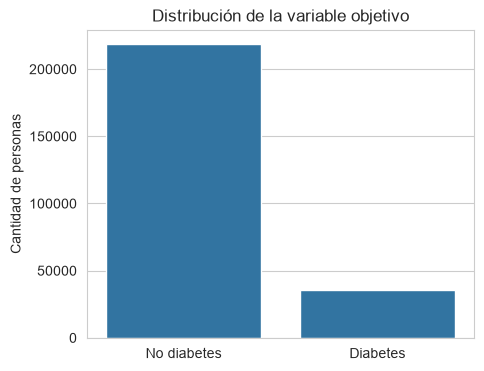

In [7]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Diabetes_binary")
plt.xticks([0, 1], ["No diabetes", "Diabetes"])
plt.title("Distribución de la variable objetivo")
plt.xlabel("")
plt.ylabel("Cantidad de personas")
plt.show()

**Pregunta: ¿está balanceada la variable objetivo?**

No. La clase "No diabetes" domina ampliamente sobre la clase "Diabetes" (proporción aproximada 86% / 14%, ver tabla anterior). Esto es un **desbalance de clases relevante**: implica que un modelo que prediga siempre "No diabetes" ya obtendría una accuracy alta sin ser útil, por lo que en la fase de modelado será necesario apoyarse en métricas como recall, F1 y ROC-AUC (y eventualmente `class_weight="balanced"` u otras estrategias de balanceo) en lugar de accuracy.

## 4. Clasificación conceptual de variables

Para facilitar la interpretación, agrupamos las variables predictoras según su naturaleza.

In [8]:
grupos_variables = {
    "Indicadores de salud": ["HighBP", "HighChol", "CholCheck", "BMI", "Stroke",
                              "HeartDiseaseorAttack", "GenHlth", "MentHlth", "PhysHlth", "DiffWalk"],
    "Hábitos": ["Smoker", "Fruits", "Veggies", "HvyAlcoholConsump", "PhysActivity"],
    "Acceso a salud": ["AnyHealthcare", "NoDocbcCost"],
    "Características demográficas": ["Sex", "Age", "Education", "Income"],
}

for grupo, cols in grupos_variables.items():
    print(f"{grupo}: {cols}")

Indicadores de salud: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Stroke', 'HeartDiseaseorAttack', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']
Hábitos: ['Smoker', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'PhysActivity']
Acceso a salud: ['AnyHealthcare', 'NoDocbcCost']
Características demográficas: ['Sex', 'Age', 'Education', 'Income']


In [9]:
binarias = [c for c in df.columns if df[c].nunique() == 2 and c != "Diabetes_binary"]
ordinales_numericas = [c for c in df.columns if c not in binarias + ["Diabetes_binary"]]

print("Variables binarias (0/1):", binarias)
print("\nVariables ordinales / numéricas:", ordinales_numericas)

Variables binarias (0/1): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

Variables ordinales / numéricas: ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']


## 5. Distribuciones de variables numéricas/ordinales clave

Antes de cruzarlas con el target, observamos su distribución general.

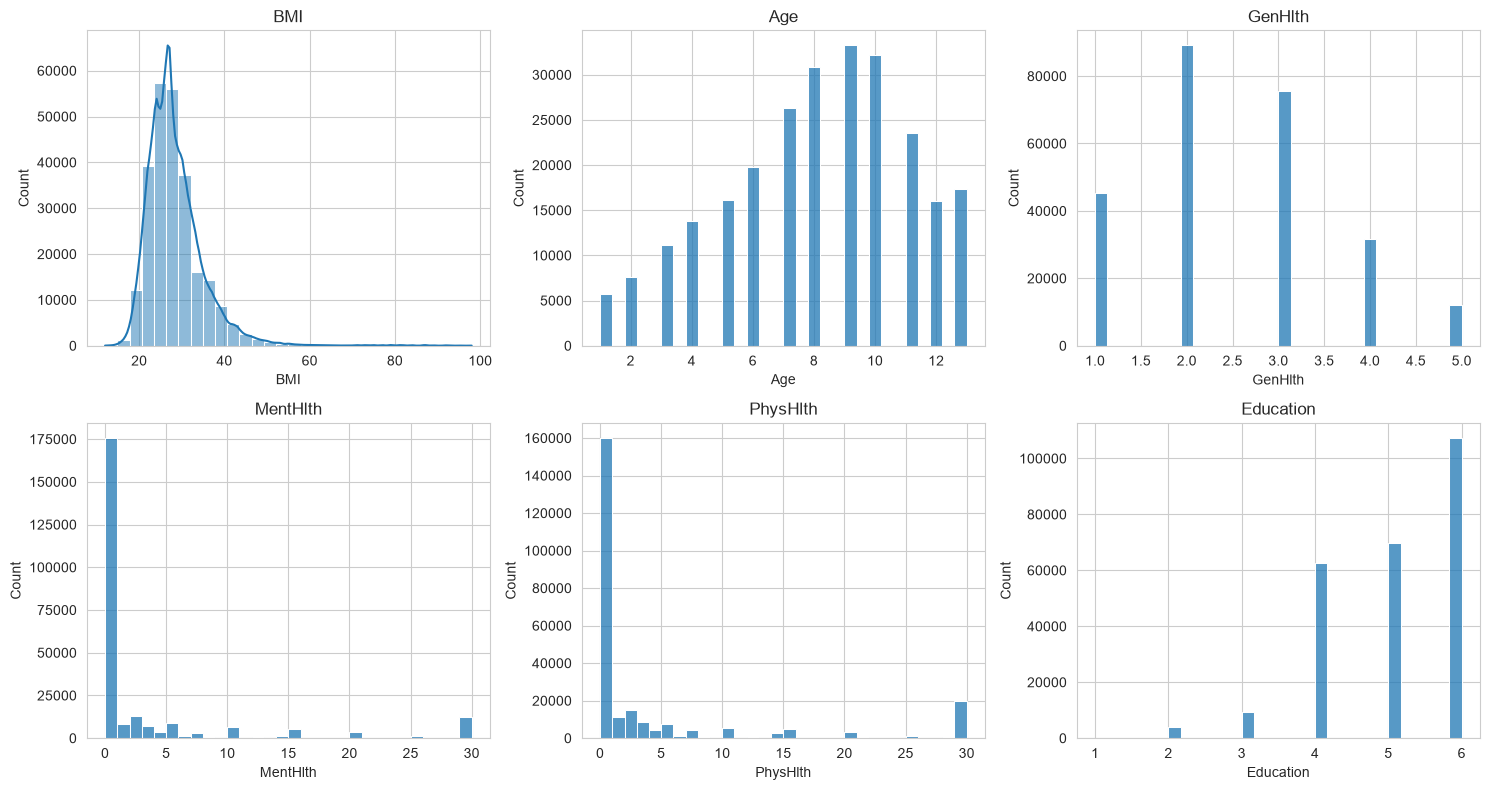

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols_dist = ["BMI", "Age", "GenHlth", "MentHlth", "PhysHlth", "Education"]
for ax, col in zip(axes.flat, cols_dist):
    sns.histplot(df[col], bins=30, ax=ax, kde=(col == "BMI"))
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Observaciones:**
- `BMI` tiene una distribución con cola larga a la derecha (valores extremos de obesidad severa).
- `Age`, `GenHlth`, `Education` e `Income` son variables ordinales codificadas en pocos niveles (categorías de la encuesta BRFSS), no continuas.
- `MentHlth` y `PhysHlth` (días de mala salud mental/física en los últimos 30 días) están muy concentradas en 0, con una cola larga hacia 30.

## 6. Diabetes según edad

`Age` es una variable ordinal con 13 categorías correspondientes a rangos de 5 años (`_AGEG5YR` del codebook BRFSS): 1 = 18-24 años, ..., 9 = 60-64 años, ..., 13 = 80 años o más.

In [11]:
AGE_LABELS = {
    1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39", 5: "40-44",
    6: "45-49", 7: "50-54", 8: "55-59", 9: "60-64", 10: "65-69",
    11: "70-74", 12: "75-79", 13: "80+",
}

df["AgeGroup"] = df["Age"].map(AGE_LABELS)

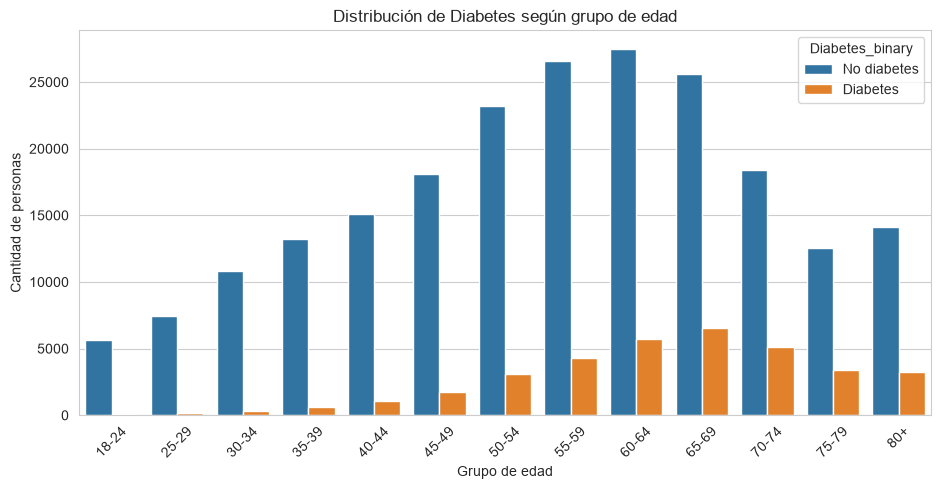

In [12]:
order = [AGE_LABELS[k] for k in sorted(AGE_LABELS)]
plt.figure(figsize=(11, 5))
sns.countplot(data=df, x="AgeGroup", hue="Diabetes_binary", order=order)
plt.title("Distribución de Diabetes según grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de personas")
plt.xticks(rotation=45)
plt.legend(title="Diabetes_binary", labels=["No diabetes", "Diabetes"])
plt.show()

In [13]:
tasa_por_edad = df.groupby("AgeGroup")["Diabetes_binary"].mean().reindex(order) * 100
tasa_por_edad.round(2)

AgeGroup
18-24     1.37
25-29     1.84
30-34     2.82
35-39     4.53
40-44     6.50
45-49     8.79
50-54    11.74
55-59    13.83
60-64    17.25
65-69    20.37
70-74    21.85
75-79    21.30
80+      18.48
Name: Diabetes_binary, dtype: float64

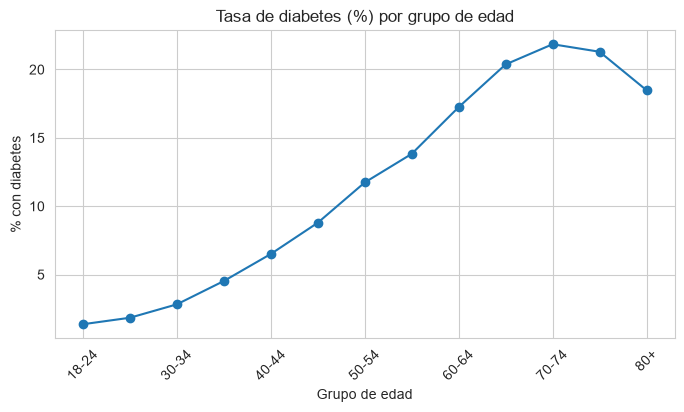

In [14]:
plt.figure(figsize=(8, 4))
tasa_por_edad.plot(marker="o")
plt.title("Tasa de diabetes (%) por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("% con diabetes")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Pregunta: ¿la distribución de diabetes cambia según los grupos de edad?**

Sí, claramente. La tasa de diabetes pasa de ~1.4% en el grupo de 18-24 años a un máximo de ~21.9% en el grupo de 70-74 años, y se estabiliza (e incluso desciende levemente) en 75-79 y 80+. El aumento es prácticamente monótono con la edad hasta el rango de adultos mayores jóvenes, lo que confirma que `Age` será una variable predictiva relevante.

## 7. Diabetes y BMI

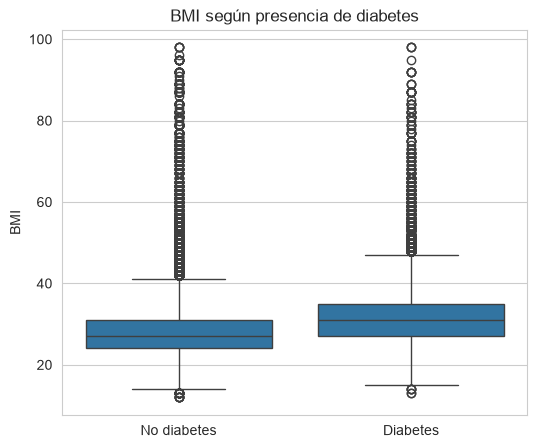

In [15]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="Diabetes_binary", y="BMI")
plt.xticks([0, 1], ["No diabetes", "Diabetes"])
plt.title("BMI según presencia de diabetes")
plt.xlabel("")
plt.show()

In [16]:
df.groupby("Diabetes_binary")["BMI"].describe()

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,,,,,,,,
0.0,218334.0,27.805770,6.291414,12.0,24.0,27.0,31.0,98.0
1.0,35346.0,31.944011,7.363401,13.0,27.0,31.0,35.0,98.0


**Pregunta: ¿existen diferencias en BMI entre las personas con y sin diabetes?**

Sí. El grupo con diabetes presenta una mediana de BMI notablemente más alta que el grupo sin diabetes, con una distribución desplazada hacia valores de sobrepeso/obesidad. Es una de las variables con mayor potencial predictivo.

## 8. Hipertensión (`HighBP`) y diabetes

In [17]:
ct_bp = pd.crosstab(df["HighBP"], df["Diabetes_binary"], normalize="index") * 100
ct_bp.index = ["Sin hipertensión", "Con hipertensión"]
ct_bp.columns = ["No diabetes (%)", "Diabetes (%)"]
ct_bp.round(2)

,No diabetes (%),Diabetes (%)
Sin hipertensión,93.96,6.04
Con hipertensión,75.55,24.45


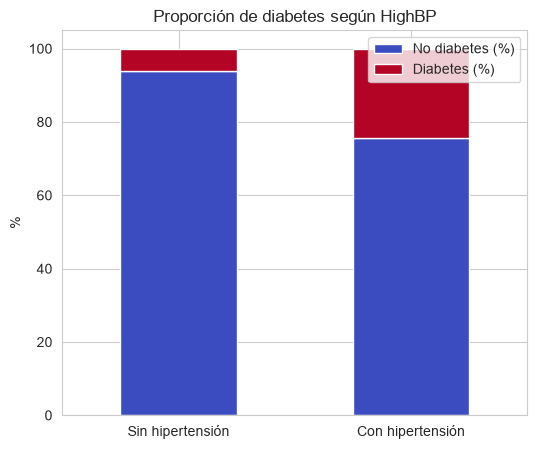

In [18]:
ct_bp.plot(kind="bar", stacked=True, figsize=(6, 5), colormap="coolwarm")
plt.title("Proporción de diabetes según HighBP")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.show()

**Pregunta: ¿qué proporción de personas con presión arterial alta pertenece a la clase de diabetes?**

La proporción de diabetes es sustancialmente mayor entre quienes reportan hipertensión (`HighBP=1`) que entre quienes no la reportan. `HighBP` aparece como un indicador de riesgo relevante.

## 9. Colesterol alto (`HighChol`) y diabetes

In [19]:
ct_chol = pd.crosstab(df["HighChol"], df["Diabetes_binary"], normalize="index") * 100
ct_chol.index = ["Sin colesterol alto", "Con colesterol alto"]
ct_chol.columns = ["No diabetes (%)", "Diabetes (%)"]
ct_chol.round(2)

,No diabetes (%),Diabetes (%)
Sin colesterol alto,92.02,7.98
Con colesterol alto,77.99,22.01


### Cruce combinado: HighBP + HighChol + Diabetes

In [20]:
combo = df.groupby(["HighBP", "HighChol"])["Diabetes_binary"].mean().mul(100).round(2)
combo = combo.rename("Tasa de diabetes (%)").reset_index()
combo["HighBP"] = combo["HighBP"].map({0: "Sin HTA", 1: "Con HTA"})
combo["HighChol"] = combo["HighChol"].map({0: "Sin colesterol alto", 1: "Con colesterol alto"})
combo

,HighBP,HighChol,Tasa de diabetes (%)
0,Sin HTA,Sin colesterol alto,4.19
1,Sin HTA,Con colesterol alto,10.42
2,Con HTA,Sin colesterol alto,16.73
3,Con HTA,Con colesterol alto,29.71


**Observación:** la tasa de diabetes crece de forma acumulativa: es más baja cuando no hay hipertensión ni colesterol alto, intermedia cuando hay solo una de las dos condiciones, y más alta cuando ambas están presentes. Esto sugiere un efecto combinado de comorbilidades cardiovasculares sobre el riesgo de diabetes.

## 10. Otros indicadores de salud vs. diabetes

Repetimos el mismo tipo de cruce para otras variables binarias de salud relevantes.

In [21]:
otras_binarias = ["Stroke", "HeartDiseaseorAttack", "DiffWalk", "PhysActivity",
                  "Smoker", "HvyAlcoholConsump", "Fruits", "Veggies"]

tabla_otras = pd.DataFrame({
    var: df.groupby(var)["Diabetes_binary"].mean().mul(100).round(2)
    for var in otras_binarias
}).T
tabla_otras.columns = ["Diabetes % (valor=0)", "Diabetes % (valor=1)"]
tabla_otras

,Diabetes % (valor=0),Diabetes % (valor=1)
Stroke,13.18,31.75
HeartDiseaseorAttack,11.95,32.97
DiffWalk,10.53,30.75
PhysActivity,21.14,11.61
Smoker,12.06,16.29
HvyAlcoholConsump,14.42,5.84
Fruits,15.79,12.86
Veggies,18.00,12.99


**Observaciones:**
- `Stroke`, `HeartDiseaseorAttack` y `DiffWalk` muestran una diferencia grande: quienes reportan estas condiciones tienen una tasa de diabetes considerablemente mayor.
- `PhysActivity`, `Fruits` y `Veggies` muestran el patrón inverso y más moderado: hábitos saludables se asocian a una menor tasa de diabetes.
- `HvyAlcoholConsump` muestra, algo contraintuitivamente, una tasa de diabetes *menor* entre quienes reportan consumo excesivo de alcohol. Esto probablemente refleje sesgos de la encuesta (autoreporte, factores de confusión como edad) más que una relación causal protectora, y debe interpretarse con cautela.

## 11. Características demográficas: Sexo, Educación e Ingreso

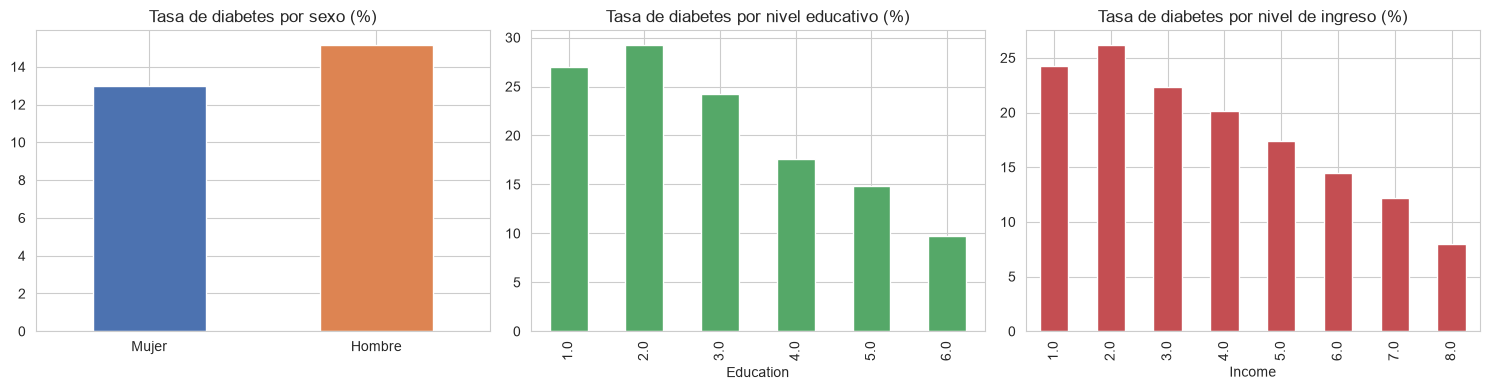

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

tasa_sex = df.groupby("Sex")["Diabetes_binary"].mean() * 100
tasa_sex.index = ["Mujer", "Hombre"]
tasa_sex.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Tasa de diabetes por sexo (%)")
axes[0].tick_params(axis="x", rotation=0)

tasa_edu = df.groupby("Education")["Diabetes_binary"].mean() * 100
tasa_edu.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Tasa de diabetes por nivel educativo (%)")

tasa_inc = df.groupby("Income")["Diabetes_binary"].mean() * 100
tasa_inc.plot(kind="bar", ax=axes[2], color="#C44E52")
axes[2].set_title("Tasa de diabetes por nivel de ingreso (%)")

plt.tight_layout()
plt.show()

**Observaciones:**
- La diferencia por `Sex` es pequeña.
- La tasa de diabetes **disminuye** a medida que aumenta el nivel educativo (`Education`) y el nivel de ingreso (`Income`), lo que sugiere una asociación con determinantes socioeconómicos de la salud (acceso a atención médica, alimentación, etc.).

## 12. Salud general (`GenHlth`) vs. diabetes

`GenHlth` es la autopercepción de salud general (1=excelente ... 5=mala).

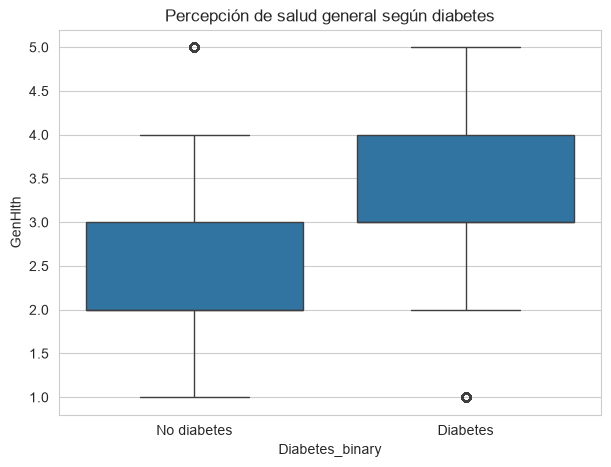

In [23]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Diabetes_binary", y="GenHlth")
plt.xticks([0, 1], ["No diabetes", "Diabetes"])
plt.title("Percepción de salud general según diabetes")
plt.show()

In [24]:
pd.crosstab(df["GenHlth"], df["Diabetes_binary"], normalize="index").mul(100).round(2)

Diabetes_binary,0.0,1.0
GenHlth,,
1.0,97.48,2.52
2.0,92.84,7.16
3.0,82.21,17.79
4.0,68.99,31.01
5.0,62.11,37.89


**Observación:** a medida que empeora la autopercepción de salud general, aumenta claramente la proporción de personas con diabetes. Es, junto con `BMI` y `Age`, una de las variables con relación más fuerte y consistente con el target.

## 13. Matriz de correlación

**Advertencia:** correlación no implica causalidad. La matriz solo sirve para detectar asociaciones lineales entre variables, no para afirmar relaciones causa-efecto.

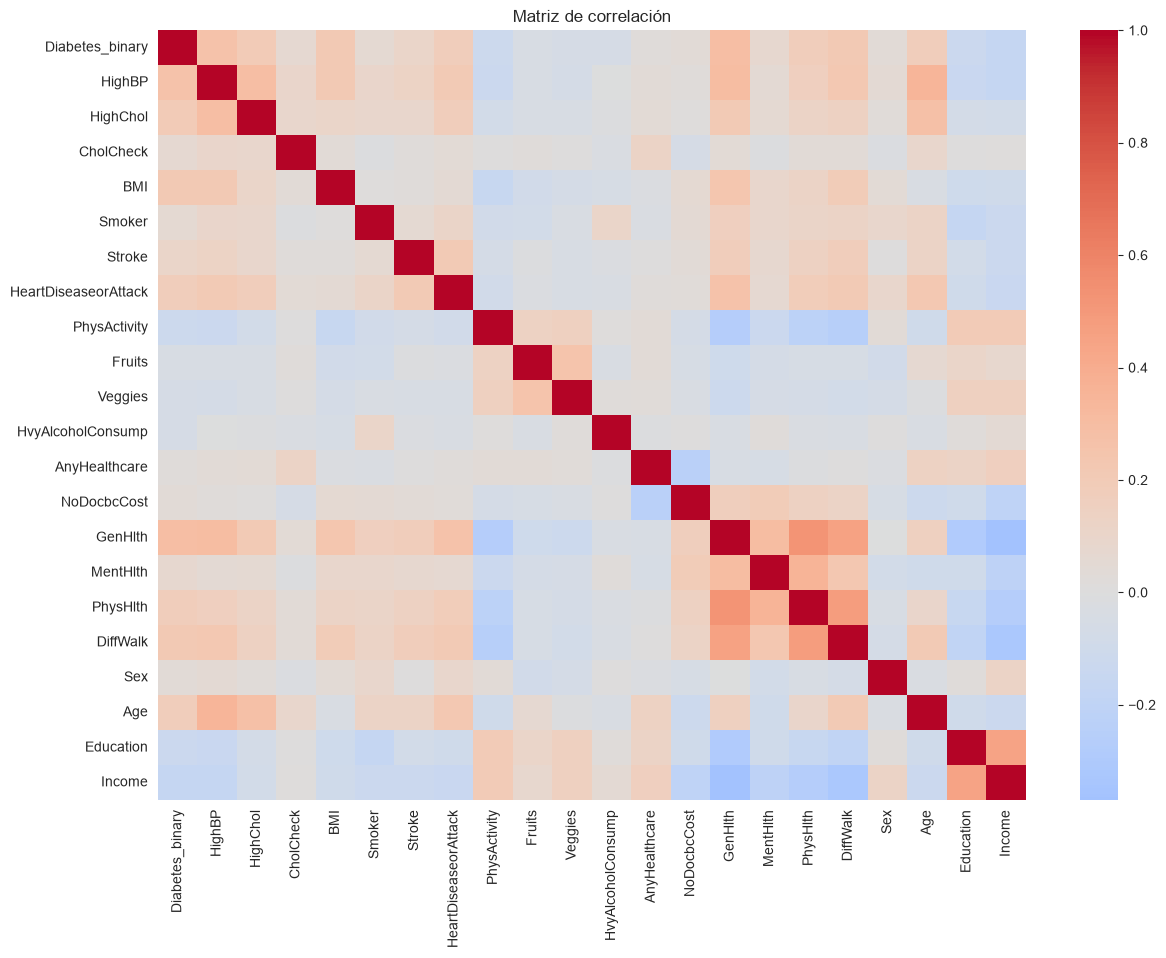

In [25]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación")
plt.show()

In [26]:
corr_target = corr["Diabetes_binary"].drop("Diabetes_binary").sort_values(key=abs, ascending=False)
corr_target.round(3)

GenHlth                 0.294
HighBP                  0.263
DiffWalk                0.218
BMI                     0.217
HighChol                0.200
Age                     0.177
HeartDiseaseorAttack    0.177
PhysHlth                0.171
Income                 -0.164
Education              -0.124
PhysActivity           -0.118
Stroke                  0.106
MentHlth                0.069
CholCheck               0.065
Smoker                  0.061
HvyAlcoholConsump      -0.057
Veggies                -0.057
Fruits                 -0.041
NoDocbcCost             0.031
Sex                     0.031
AnyHealthcare           0.016
Name: Diabetes_binary, dtype: float64

**Observaciones:**
- Las variables con mayor correlación (en valor absoluto) con `Diabetes_binary` son `GenHlth`, `HighBP`, `BMI`, `DiffWalk`, `HighChol` y `Age`, consistente con lo observado en los cruces individuales de las secciones anteriores.
- No se observan pares de variables predictoras con correlación extremadamente alta entre sí (>0.8) que sugieran redundancia severa a eliminar antes del modelado, aunque `GenHlth` correlaciona moderadamente con `PhysHlth` y `DiffWalk`, lo cual es esperable conceptualmente.

## 14. Resumen del EDA

- El dataset tiene 253,680 registros, 21 variables predictoras y ninguna con valores nulos.
- El target está **fuertemente desbalanceado** (~86% sin diabetes / ~14% con diabetes): condiciona toda la fase de modelado a priorizar recall/F1/ROC-AUC sobre accuracy.
- Las variables con relación más clara y consistente con el target son: `GenHlth`, `BMI`, `HighBP`, `HighChol`, `Age` y `DiffWalk`.
- Existe evidencia de un efecto acumulativo entre comorbilidades (hipertensión + colesterol alto) sobre el riesgo de diabetes.
- Los determinantes socioeconómicos (`Education`, `Income`) muestran una asociación inversa con la tasa de diabetes.
- Ninguna de estas relaciones debe interpretarse como causal; son asociaciones observadas en datos de encuesta (BRFSS 2015) y sirven como base para la siguiente etapa: preparación de datos y modelado.